In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.0 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [ ]:
# Load MNIST data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def model_builder(hp):
    model = keras.Sequential()

    # 1. Flatten Layer (Input)
    model.add(keras.layers.Flatten(input_shape=(28, 28)))

    # 2. Tunable Hidden Layer
    # hp.Int defines a range of integers to try.
    # We ask it to try values between 32 and 512, in steps of 32 (e.g., 32, 64, 96...)
    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    model.add(keras.layers.Dense(units=hp_units, activation='relu'))

    # 3. Output Layer (Fixed at 10 for MNIST)
    model.add(keras.layers.Dense(10, activation='softmax'))

    # 4. Tune the Learning Rate
    # hp.Choice picks from a specific list of values
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy', # We want to maximize validation accuracy
                     max_epochs=10,            # Max epochs per trial
                     factor=3,                 # Reduction factor for the algorithm
                     directory='my_dir',       # Folder to save results
                     project_name='intro_to_kt')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Run the search
# This will take a few minutes as it trains multiple models
tuner.search(x_train, y_train,
             epochs=10,
             validation_split=0.2,
             callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete.
The optimal number of units in the first densely-connected layer is {best_hps.get('units')}
and the optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

Trial 30 Complete [00h 01m 29s]
val_accuracy: 0.969083309173584

Best val_accuracy So Far: 0.9799166917800903
Total elapsed time: 00h 15m 13s

The hyperparameter search is complete. 
The optimal number of units in the first densely-connected layer is 352 
and the optimal learning rate for the optimizer is 0.001.



In [ ]:
# Build the model with the optimal hyperparameters
model = tuner.hypermodel.build(best_hps)

# Train the model
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8819 - loss: 0.4059 - val_accuracy: 0.9632 - val_loss: 0.1260
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9687 - loss: 0.1036 - val_accuracy: 0.9719 - val_loss: 0.0919
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9799 - loss: 0.0649 - val_accuracy: 0.9733 - val_loss: 0.0858
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9864 - loss: 0.0443 - val_accuracy: 0.9747 - val_loss: 0.0854
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9915 - loss: 0.0275 - val_accuracy: 0.9741 - val_loss: 0.0915
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9929 - loss: 0.0224 - val_accuracy: 0.9789 - val_loss: 0.0818
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9952 - loss: 0.0156 - val_accuracy: 0.9772 - val_loss: 0.0884
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9963 - loss: 0.0128 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.1086
[Test Loss, Test Accuracy]: [0.09186771512031555, 0.9779000282287598]


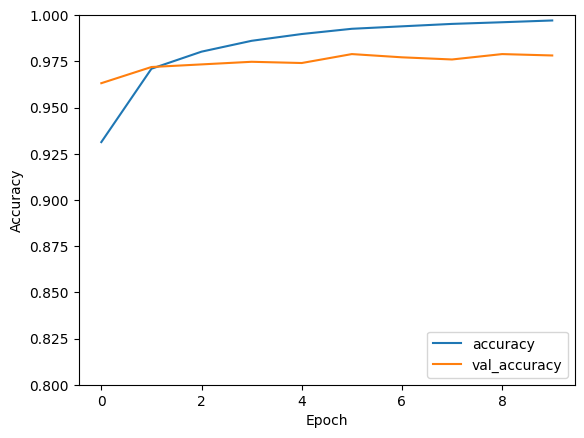

In [ ]:
eval_result = model.evaluate(x_test, y_test)
print(f"[Test Loss, Test Accuracy]: {eval_result}")

# Generate a plot of accuracy over time
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1])
plt.legend(loc='lower right')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


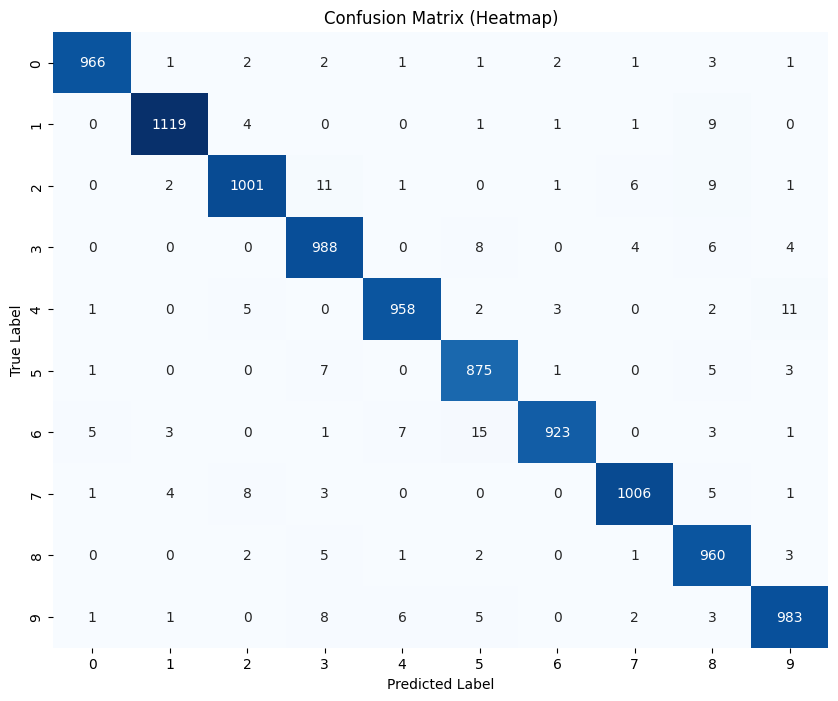

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions for all test data
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# 3. Plot it nicely using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Heatmap)')
plt.show()

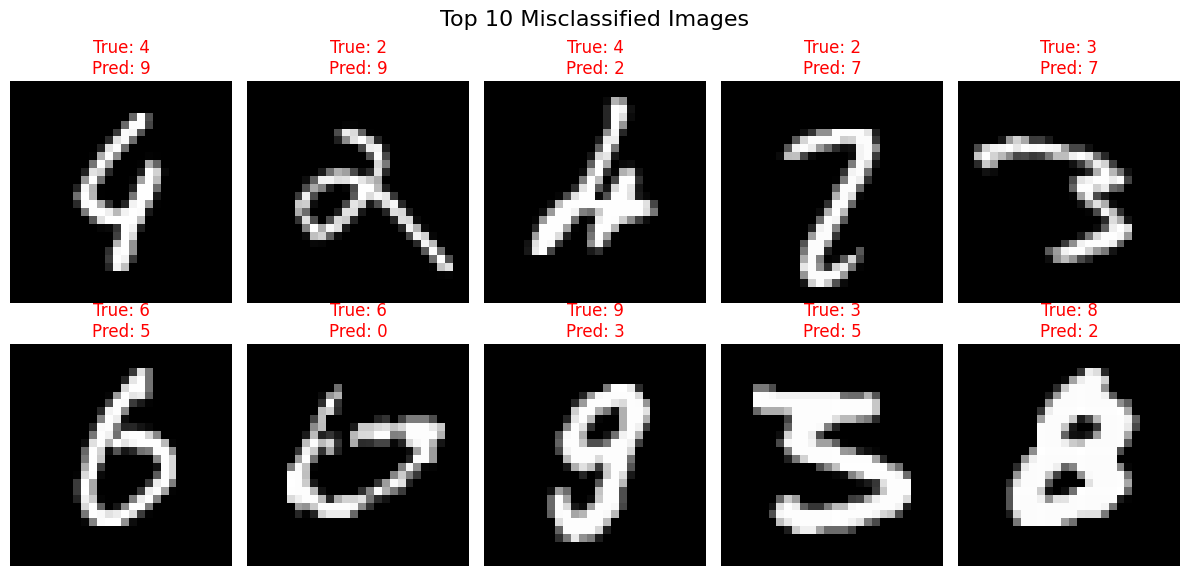

In [ ]:
# Find indices where predictions didn't match truth
errors = (y_pred_classes - y_test != 0)
y_pred_classes_errors = y_pred_classes[errors]
y_test_errors = y_test[errors]
x_test_errors = x_test[errors]

# Plot the first 10 errors
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1) # 2 rows, 5 columns
    plt.imshow(x_test_errors[i], cmap='gray')
    plt.title(f"True: {y_test_errors[i]}\nPred: {y_pred_classes_errors[i]}", color='red')
    plt.axis('off')

plt.suptitle("Top 10 Misclassified Images", fontsize=16)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


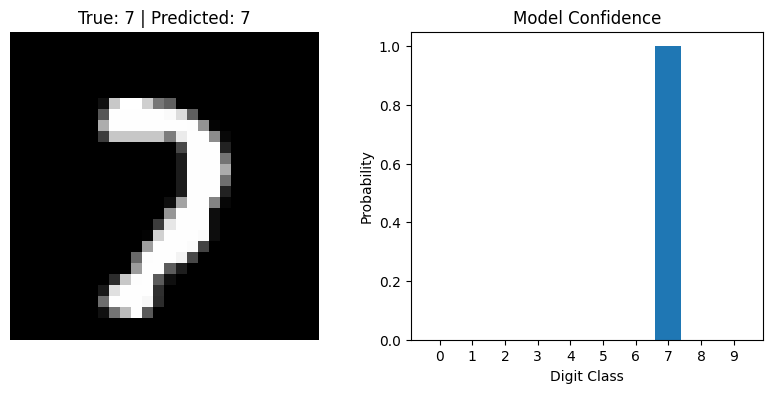

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a random test image
index = np.random.randint(0, len(x_test))
sample_image = x_test[index]
true_label = y_test[index]

# Predict
prediction = model.predict(sample_image.reshape(1, 28, 28))
predicted_label = np.argmax(prediction)

# Plot image + prediction
plt.figure(figsize=(10,4))

# Left: digit image
plt.subplot(1,2,1)
plt.imshow(sample_image, cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_label}")
plt.axis('off')

# Right: probability bars
plt.subplot(1,2,2)
plt.bar(range(10), prediction[0])
plt.xticks(range(10))
plt.xlabel("Digit Class")
plt.ylabel("Probability")
plt.title("Model Confidence")

plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


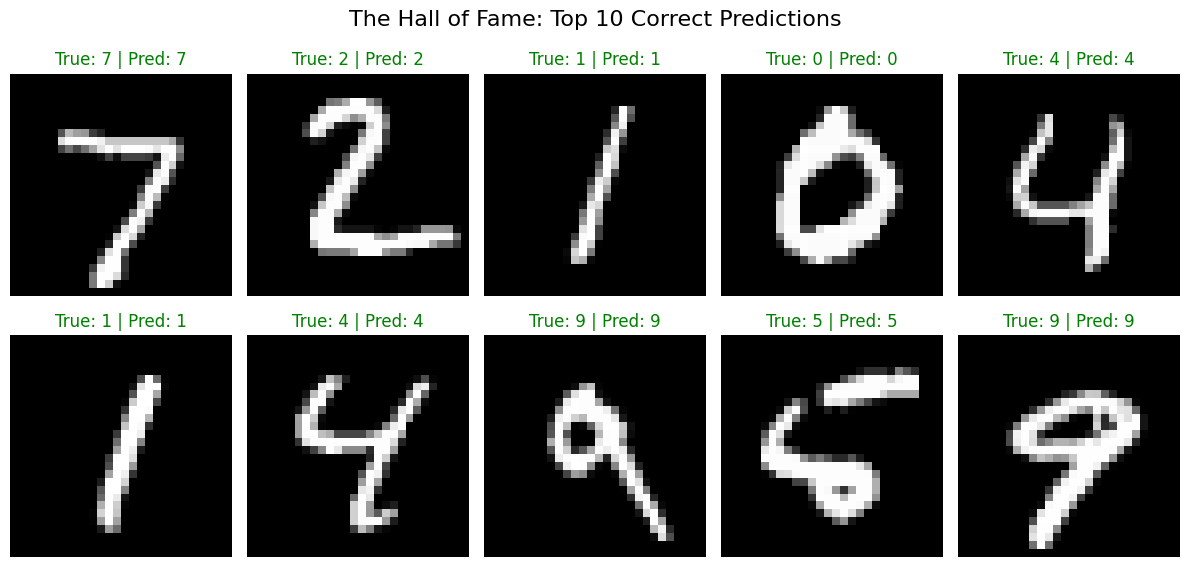

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get predictions (if you haven't already in the previous step)
# This assumes 'model' is your trained model and 'x_test' is your data
predictions = model.predict(x_test)
y_pred_classes = np.argmax(predictions, axis=1)

# 2. Find indices where predictions MATCH the true labels
correct_indices = np.where(y_pred_classes == y_test)[0]

# 3. Plot the first 10 correctly classified images
plt.figure(figsize=(12, 6))

for i in range(10):
    # Get the index of the i-th correct prediction
    idx = correct_indices[i]

    # Create a subplot (2 rows, 5 columns)
    plt.subplot(2, 5, i + 1)

    # Display the image
    plt.imshow(x_test[idx], cmap='gray')

    # Add title with the label (Green color for success!)
    plt.title(f"True: {y_test[idx]} | Pred: {y_pred_classes[idx]}", color='green', fontsize=12)

    # Hide the axes for a cleaner look
    plt.axis('off')

plt.suptitle("The Hall of Fame: Top 10 Correct Predictions", fontsize=16)
plt.tight_layout()
plt.show()